### STEP: Introduction
This project analyzes customer purchase behavior in an e-commerce platform. 
The focus is on understanding spending patterns, coupon usage, and order frequency 
using statistical methods such as probability distributions, sampling techniques, 
confidence intervals, and hypothesis testing.

### STEP-2 : OBJECTIVE
To analyze order behavior, spending distribution, and coupon usage using 
advanced statistical techniques.


### STEP-3 : Dataset Generation

In [1]:
import numpy as np
import pandas as pd 

In [2]:
np.random.seed(42)
n = 10000

In [3]:
df = pd.DataFrame(
    {
    "Order_ID": np.arange(1, n+1),
    "Customer_ID": np.random.randint(1000, 5000, n),
    "Region": np.random.choice(['North','South','East','West'], n),
    "Order_Amount": np.random.lognormal(7, 0.5, n),
    "Discount_Percentage": np.random.uniform(0,50,n),
    "Coupon_Used": np.random.binomial(1,0.4,n),
    "Orders_in_Month": np.random.binomial(10,0.5,n),
    "Order_Date": pd.date_range("2023-01-01", periods=n, freq="H")
 
    }
)

C:\Users\Umme Amreen Saba\AppData\Local\Temp\ipykernel_23736\55083025.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "Order_Date": pd.date_range("2023-01-01", periods=n, freq="H")


In [48]:
df.head(3)

,Order_ID,Customer_ID,Region,Order_Amount,Discount_Percentage,Coupon_Used,Orders_in_Month,Order_Date,norm,z,log
0,1,4174,East,735.632183,48.091658,1,6,2023-01-01 00:00:00,0.083298,-0.772921,6.600730
1,2,4507,South,1225.107365,29.486441,1,7,2023-01-01 01:00:00,0.152178,-0.037162,7.110784
2,3,1860,North,1379.656844,39.369121,0,3,2023-01-01 02:00:00,0.173927,0.195150,7.229590


In [5]:
df.head()

,Order_ID,Customer_ID,Region,Order_Amount,Discount_Percentage,Coupon_Used,Orders_in_Month,Order_Date
0,1,4174,East,735.632183,48.091658,1,6,2023-01-01 00:00:00
1,2,4507,South,1225.107365,29.486441,1,7,2023-01-01 01:00:00
2,3,1860,North,1379.656844,39.369121,0,3,2023-01-01 02:00:00
3,4,2294,South,946.443410,2.268863,1,5,2023-01-01 03:00:00
4,5,2130,East,914.855546,5.326835,1,4,2023-01-01 04:00:00


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order_ID             10000 non-null  int64         
 1   Customer_ID          10000 non-null  int32         
 2   Region               10000 non-null  object        
 3   Order_Amount         10000 non-null  float64       
 4   Discount_Percentage  10000 non-null  float64       
 5   Coupon_Used          10000 non-null  int32         
 6   Orders_in_Month      10000 non-null  int32         
 7   Order_Date           10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int32(3), int64(1), object(1)
memory usage: 507.9+ KB


In [7]:
df.describe()

,Order_ID,Customer_ID,Order_Amount,Discount_Percentage,Coupon_Used,Orders_in_Month,Order_Date
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000
mean,5000.50000,3010.561100,1249.830130,24.824187,0.395800,4.984600,2023-07-28 07:30:00
min,1.00000,1000.000000,143.695780,0.003375,0.000000,0.000000,2023-01-01 00:00:00
25%,2500.75000,2001.750000,783.926070,12.331011,0.000000,4.000000,2023-04-15 03:45:00
50%,5000.50000,3004.000000,1108.199218,24.838835,0.000000,5.000000,2023-07-28 07:30:00
75%,7500.25000,4010.000000,1555.420246,37.039698,1.000000,6.000000,2023-11-09 11:15:00
max,10000.00000,4999.000000,7249.914742,49.986604,1.000000,10.000000,2024-02-21 15:00:00
std,2886.89568,1152.371939,665.266059,14.342394,0.489046,1.581396,NaN


### STEP-4: Distribution Analysis

The histogram is visualized using a dark theme to improve clarity and presentation. 
The mean value is highlighted using a red dashed line, and the distribution shows 
a right-skewed pattern.

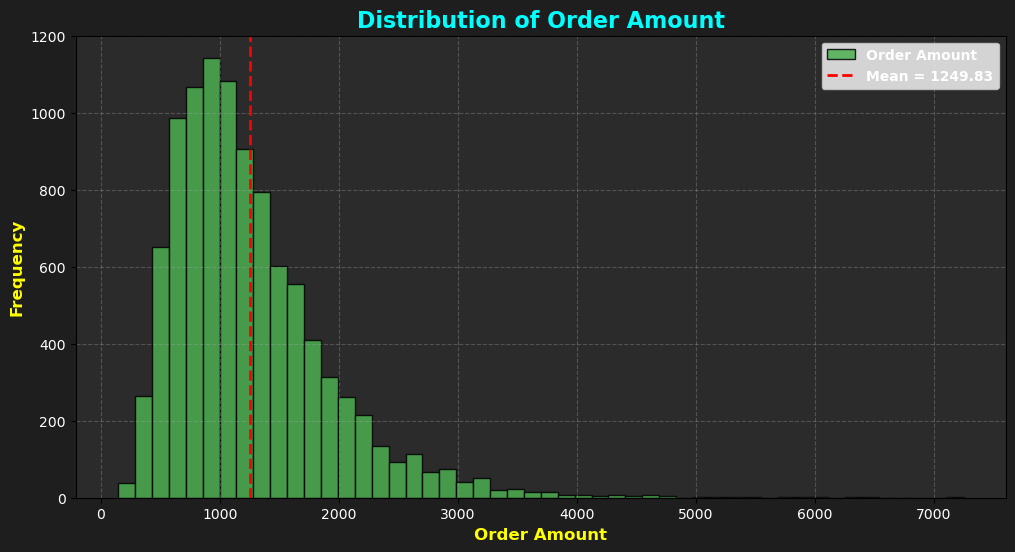

In [23]:
import matplotlib.pyplot as plt

# Outer background (dark)
plt.figure(figsize=(12,6), facecolor='#1e1e1e')

# Inner background (dark)
ax = plt.gca()
ax.set_facecolor('#2b2b2b')

# Histogram
plt.hist(df["Order_Amount"], bins=50, color='#4CAF50',
         edgecolor='black', alpha=0.85, label="Order Amount")

# Mean line
mean_val = 1249.83
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2,
            label=f"Mean = {mean_val}")

# Title (bold + color)
plt.title("Distribution of Order Amount",
          fontsize=16, fontweight='bold', color='cyan')

# Axis labels (bold + color)
plt.xlabel("Order Amount",
           fontsize=12, fontweight='bold', color='yellow')

plt.ylabel("Frequency",
           fontsize=12, fontweight='bold', color='yellow')

# Tick colors
plt.xticks(color='white')
plt.yticks(color='white')

# Grid
plt.grid(True, linestyle='--', alpha=0.3)

# Legend (bold + color)
legend = plt.legend()
for text in legend.get_texts():
    text.set_color('white')
    text.set_fontweight('bold')

# Show
plt.show()

The histogram is customized with colors and a mean line to enhance visualization. 
The red dashed line represents the average order amount, helping to understand 
the central tendency of the data.

### Skewness check

In [12]:
df["Order_Amount"].skew() 
# if > 0 right skew 

np.float64(1.7428281590323216)

### QQ plot 

In [13]:
#if not Straight line  → not normal

The QQ plot shows that the data points deviate from the straight line, 
indicating that the distribution is not normal. This confirms that the 
order amount follows a log-normal distribution.

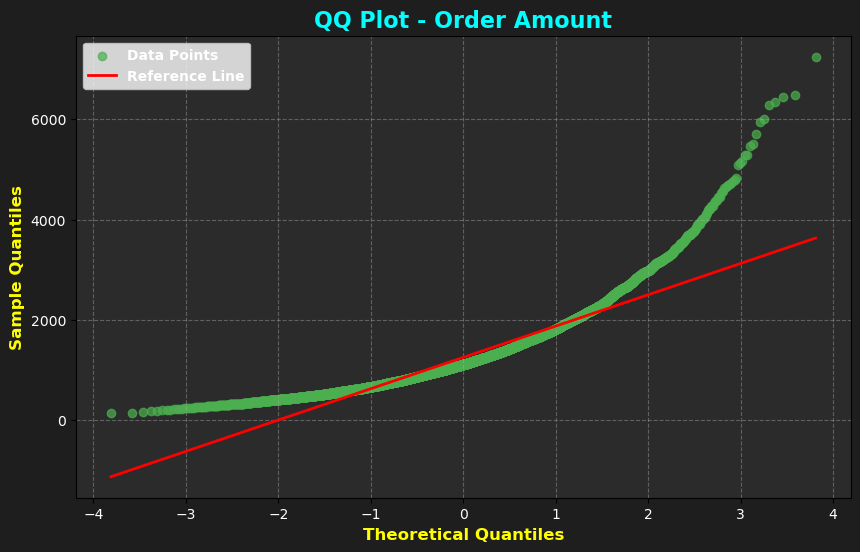

In [22]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Outer background (dark)
plt.figure(figsize=(10,6), facecolor='#1e1e1e')

# Inner background (dark)
ax = plt.gca()
ax.set_facecolor('#2b2b2b')

# QQ calculation
res = stats.probplot(df["Order_Amount"], dist="norm")

# Scatter points
plt.scatter(res[0][0], res[0][1], color='#4CAF50', alpha=0.7, label="Data Points")

# Line (reference line)
plt.plot(res[0][0], res[1][0]*res[0][0] + res[1][1],
         color='red', linewidth=2, label="Reference Line")

# Title (bold + color)
plt.title("QQ Plot - Order Amount",
          fontsize=16, fontweight='bold', color='cyan')

# Labels (bold + color)
plt.xlabel("Theoretical Quantiles",
           fontsize=12, fontweight='bold', color='yellow')

plt.ylabel("Sample Quantiles",
           fontsize=12, fontweight='bold', color='yellow')

# Tick colors
plt.xticks(color='white')
plt.yticks(color='white')

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

# Legend (bold + color)
legend = plt.legend()
for text in legend.get_texts():
    text.set_color('white')
    text.set_fontweight('bold')

# Show
plt.show()

### strp-4 Probability

### Coupon (Bernoulli)

In [24]:
df["Coupon_Used"].value_counts(normalize=True)

Coupon_Used
0    0.6042
1    0.3958
Name: proportion, dtype: float64

### Binomial

In [25]:
from scipy.stats import binom
binom.pmf(5,10,0.5)

np.float64(0.24609375000000003)

### Poisson

In [26]:
from scipy.stats import poisson
poisson.pmf(10,20)

np.float64(0.00581630651834512)

### STEP-5 Scaling

### Normalization

In [32]:
df["norm"] = (df["Order_Amount"] - df["Order_Amount"].min()) / \
             (df["Order_Amount"].max() - df["Order_Amount"].min())
df.head()

,Order_ID,Customer_ID,Region,Order_Amount,Discount_Percentage,Coupon_Used,Orders_in_Month,Order_Date,norm,z
0,1,4174,East,735.632183,48.091658,1,6,2023-01-01 00:00:00,0.083298,-0.772921
1,2,4507,South,1225.107365,29.486441,1,7,2023-01-01 01:00:00,0.152178,-0.037162
2,3,1860,North,1379.656844,39.369121,0,3,2023-01-01 02:00:00,0.173927,0.195150
3,4,2294,South,946.443410,2.268863,1,5,2023-01-01 03:00:00,0.112964,-0.456038
4,5,2130,East,914.855546,5.326835,1,4,2023-01-01 04:00:00,0.108519,-0.503520


### Z-score

In [33]:
df["z"] = (df["Order_Amount"] - df["Order_Amount"].mean()) / df["Order_Amount"].std()
df.head()

,Order_ID,Customer_ID,Region,Order_Amount,Discount_Percentage,Coupon_Used,Orders_in_Month,Order_Date,norm,z
0,1,4174,East,735.632183,48.091658,1,6,2023-01-01 00:00:00,0.083298,-0.772921
1,2,4507,South,1225.107365,29.486441,1,7,2023-01-01 01:00:00,0.152178,-0.037162
2,3,1860,North,1379.656844,39.369121,0,3,2023-01-01 02:00:00,0.173927,0.195150
3,4,2294,South,946.443410,2.268863,1,5,2023-01-01 03:00:00,0.112964,-0.456038
4,5,2130,East,914.855546,5.326835,1,4,2023-01-01 04:00:00,0.108519,-0.503520


### Log Transform

In [35]:
import numpy as np
df["log"] = np.log(df["Order_Amount"])
df["log"].skew()

np.float64(-0.03432218119088064)

### STEP-6 Sampling

In [36]:
sample = df.sample(100)

### Stratified

df.groupby("Region").apply(lambda x: x.sample(50))

In [ ]:
### Systematic

In [40]:
df.iloc[::10].head()

,Order_ID,Customer_ID,Region,Order_Amount,Discount_Percentage,Coupon_Used,Orders_in_Month,Order_Date,norm,z,log
0,1,4174,East,735.632183,48.091658,1,6,2023-01-01 00:00:00,0.083298,-0.772921,6.600730
10,11,1466,North,1488.100125,42.180491,0,3,2023-01-01 10:00:00,0.189187,0.358157,7.305256
20,21,2685,North,2495.010930,41.007203,0,5,2023-01-01 20:00:00,0.330881,1.871703,7.822048
30,31,3324,East,533.414559,33.592099,1,6,2023-01-02 06:00:00,0.054842,-1.076886,6.279299
40,41,2082,North,982.596888,9.209426,0,4,2023-01-02 16:00:00,0.118052,-0.401694,6.890199


### CLT 

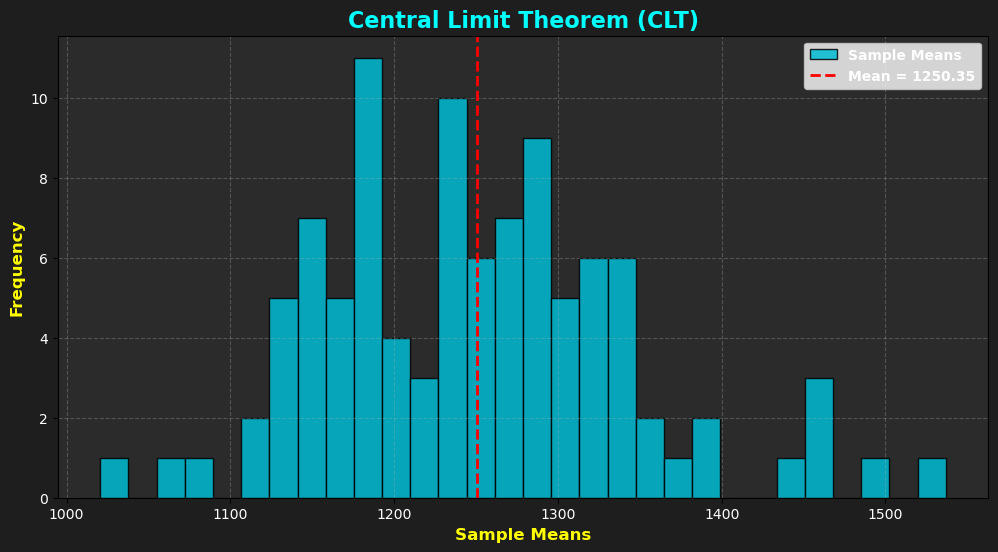

In [47]:
import matplotlib.pyplot as plt

# Generate means
means = []
for i in range(100):
    means.append(df["Order_Amount"].sample(50).mean())

# Outer background
plt.figure(figsize=(12,6), facecolor='#1e1e1e')

# Inner background
ax = plt.gca()
ax.set_facecolor('#2b2b2b')

# Histogram
plt.hist(means, bins=30, color='#00BCD4', edgecolor='black', alpha=0.85, label="Sample Means")

# Mean line
mean_val = sum(means)/len(means)
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2,
            label=f"Mean = {round(mean_val,2)}")

# Title
plt.title("Central Limit Theorem (CLT)",
          fontsize=16, fontweight='bold', color='cyan')

# Labels
plt.xlabel("Sample Means",
           fontsize=12, fontweight='bold', color='yellow')

plt.ylabel("Frequency",
           fontsize=12, fontweight='bold', color='yellow')

# Tick colors
plt.xticks(color='white')
plt.yticks(color='white')

# Grid
plt.grid(True, linestyle='--', alpha=0.3)

# Legend (bold + color)
legend = plt.legend()
for text in legend.get_texts():
    text.set_color('white')
    text.set_fontweight('bold')

plt.show()

The histogram of sample means forms an approximately normal distribution, 
even though the original data is skewed. This demonstrates the Central Limit Theorem, 
which states that the sampling distribution of the mean tends to be normal 
as the sample size increases.

This will become normal shape

### step-7 Condidence Interval

In [44]:
import numpy as np

mean = df["Order_Amount"].mean()
std = df["Order_Amount"].std()
n = len(df)

lower = mean - 1.96*(std/np.sqrt(n))
upper = mean + 1.96*(std/np.sqrt(n))

print(lower, upper)

1236.7909154982763 1262.869345008076


### STEP- 8 Hypothsis Testing

In [45]:
z = (mean - 1000)/(std/np.sqrt(n))
print(z)

37.553415945712544


Decision:
|z| > 1.96 → Reject H0

else → Accept H0

### STEP- 9 Chi-Square Test

In [46]:
import scipy.stats as stats

table = pd.crosstab(df["Region"], df["Coupon_Used"])
chi2, p, _, _ = stats.chi2_contingency(table)

print(p)

0.7596810577373727
